# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang saya gunakan adalah dataset **heart.scv**. Dataset ini saya peroleh dari kaggle. Dimana dataset tersebut memuat 12 fitur, yaitu:  Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, dan HeartDisease.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-2.3.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.3.5-cp312-cp312-macosx_10_13_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-macosx_10_13_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_10_13_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-macosx_10_13_x86_64.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_10_13_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.16.3-cp312-cp312-macosx_10_14_x86_64.whl.me

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
#Loading Dataset
df = pd.read_csv('../heart.csv')

#Tampiilkan 5 dataset teratas
print("Dataset berhasil dimuat!")
df.head()

Dataset berhasil dimuat!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
#menampilkan informasi tentang dataframe
print("Informasi DataFrame:")
df.info()

print("\nStatistik Deskriptif:")
df.describe().T

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


Dataset memiliki:

918 baris data

12 kolom (fitur):
*   6 kolom tipe numerik (int64, float64)
*   5 kolom kategorikal (object)
*   1 kolom target (HeartDisease)

Dataset ini cukup bersih, berukuran sedang, dan siap untuk eksplorasi lebih lanjut. Tidak perlu penggabungan atau pembersihan kompleks.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
#Cek Missing Values
print(f"\nJumlah missing values: {df.isnull().sum().sum()}")

#Cek duuplikat
print(f"\nJumlah duplikat: {df.duplicated().sum()}")


Jumlah missing values: 0

Jumlah duplikat: 0


In [6]:
#Target
target = 'HeartDisease'

#Tentukan fitur numerik & kategorikal

numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

binary_features = ['FastingBS']   # tetap 0/1 → tidak discaling

categorical_features = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

# Semua fitur kecuali target
feature_cols = numeric_features + binary_features + categorical_features

X = df[feature_cols]
y = df[target]

# ColumnTransformer: Encoding & Scaling

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # agar FastingBS tetap ikut tanpa scaling
)

#Fit + transform dataset

X_processed = preprocessor.fit_transform(X)

# Ambil nama kolom hasil encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

processed_feature_names = (
    numeric_features +
    list(encoded_cat_cols) +
    binary_features
)

# Buat dataframe hasil transformasi
X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)


#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

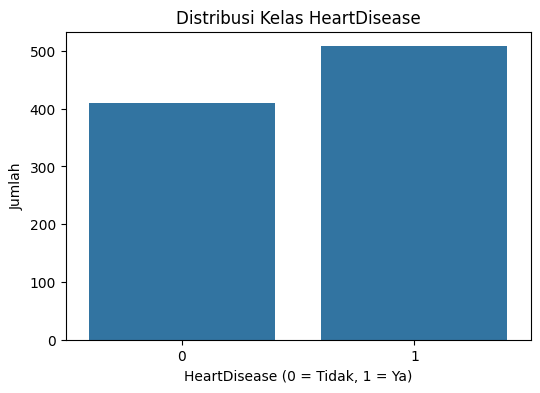

In [7]:
#Distribusi Target (HeartDisease)
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribusi Kelas HeartDisease')
plt.xlabel('HeartDisease (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()


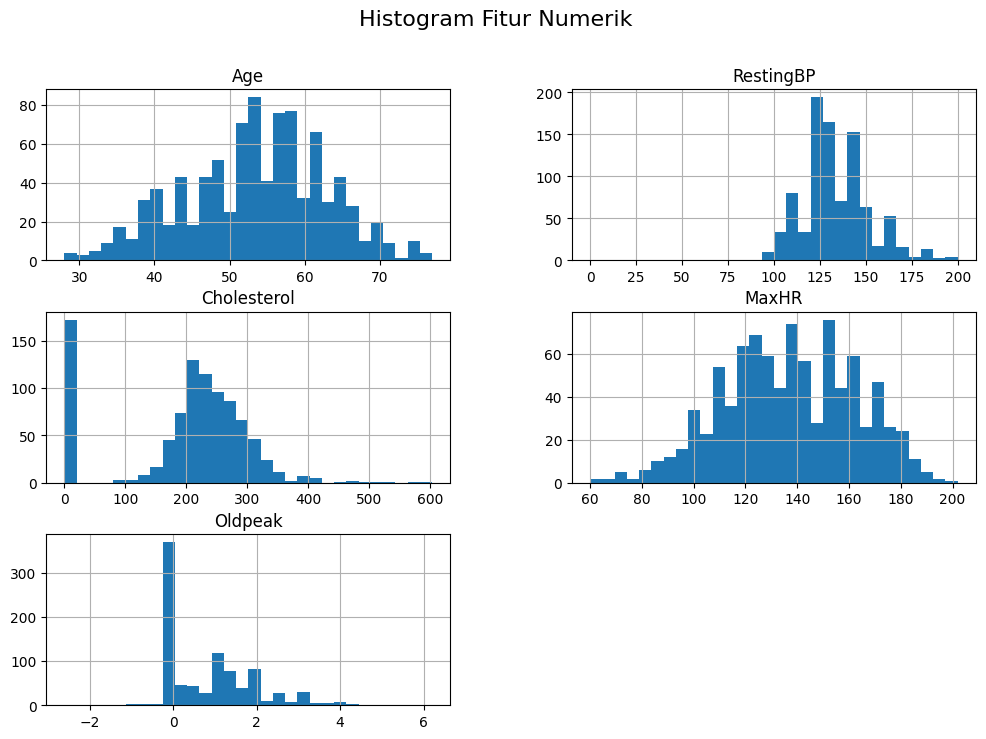

In [8]:
#Histogram Fitur Numerik
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

df[numeric_cols].hist(figsize=(12,8), bins=30)
plt.suptitle('Histogram Fitur Numerik', fontsize=16)
plt.show()


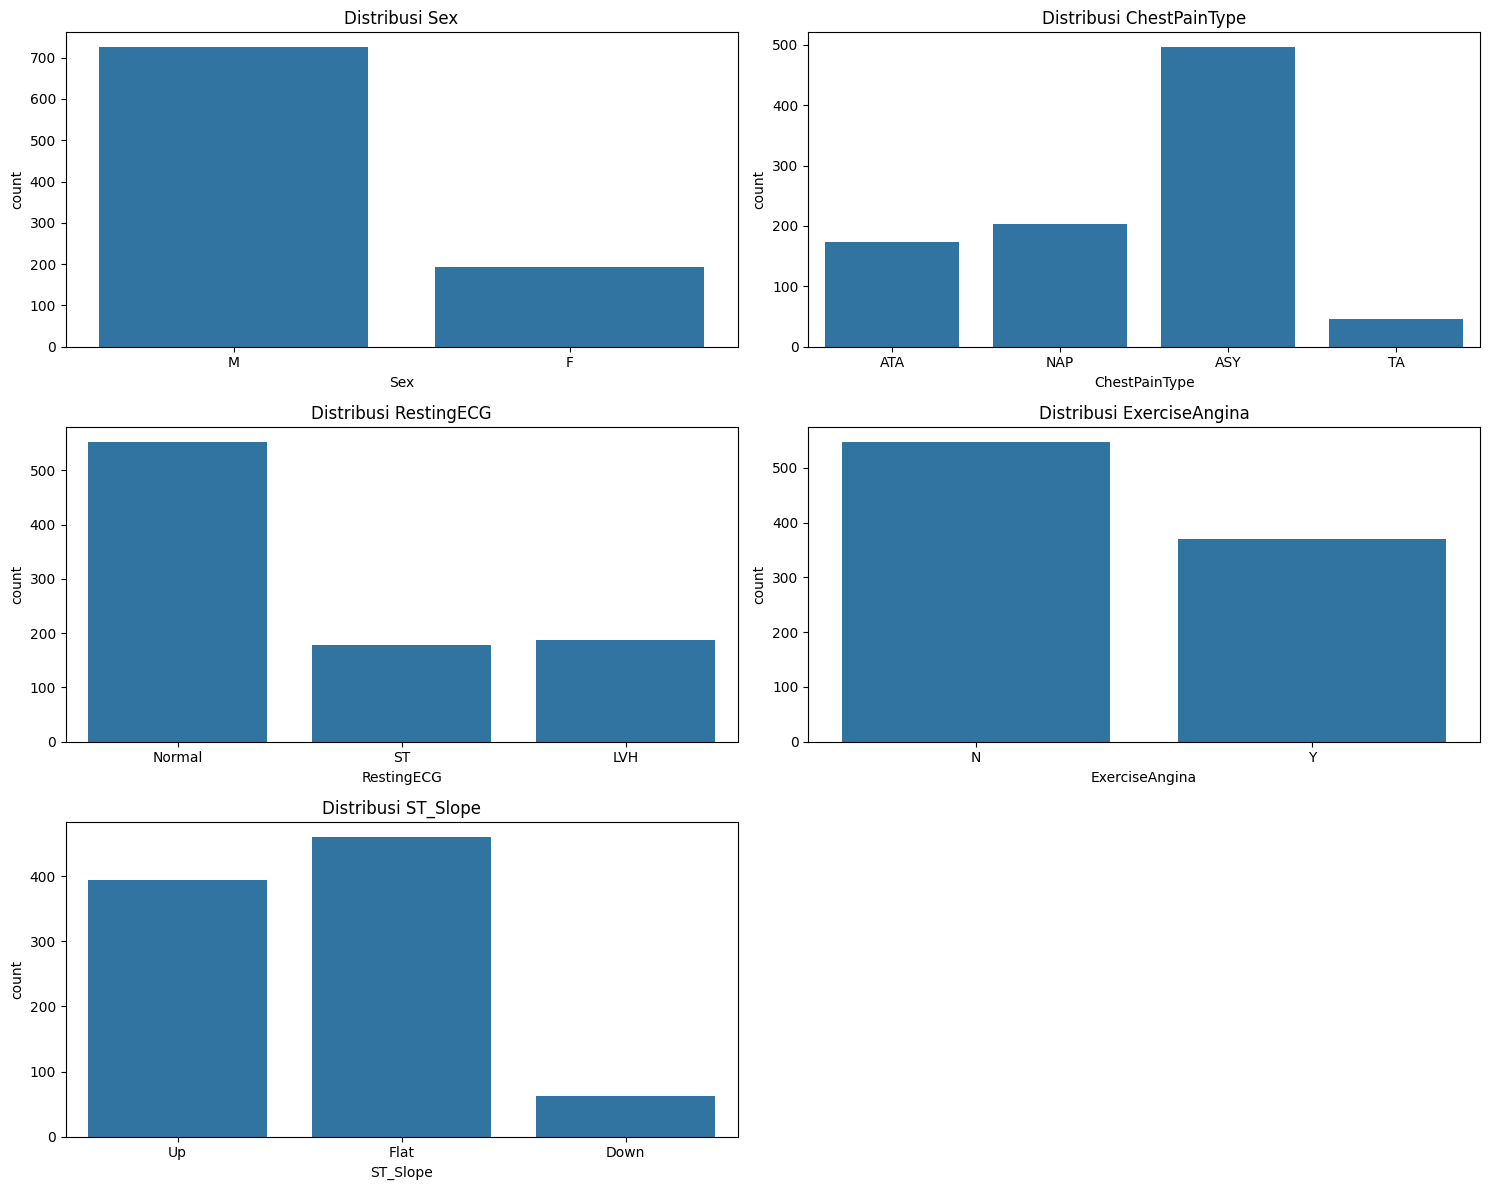

In [9]:
#Countplot Fitur Kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(15,12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()


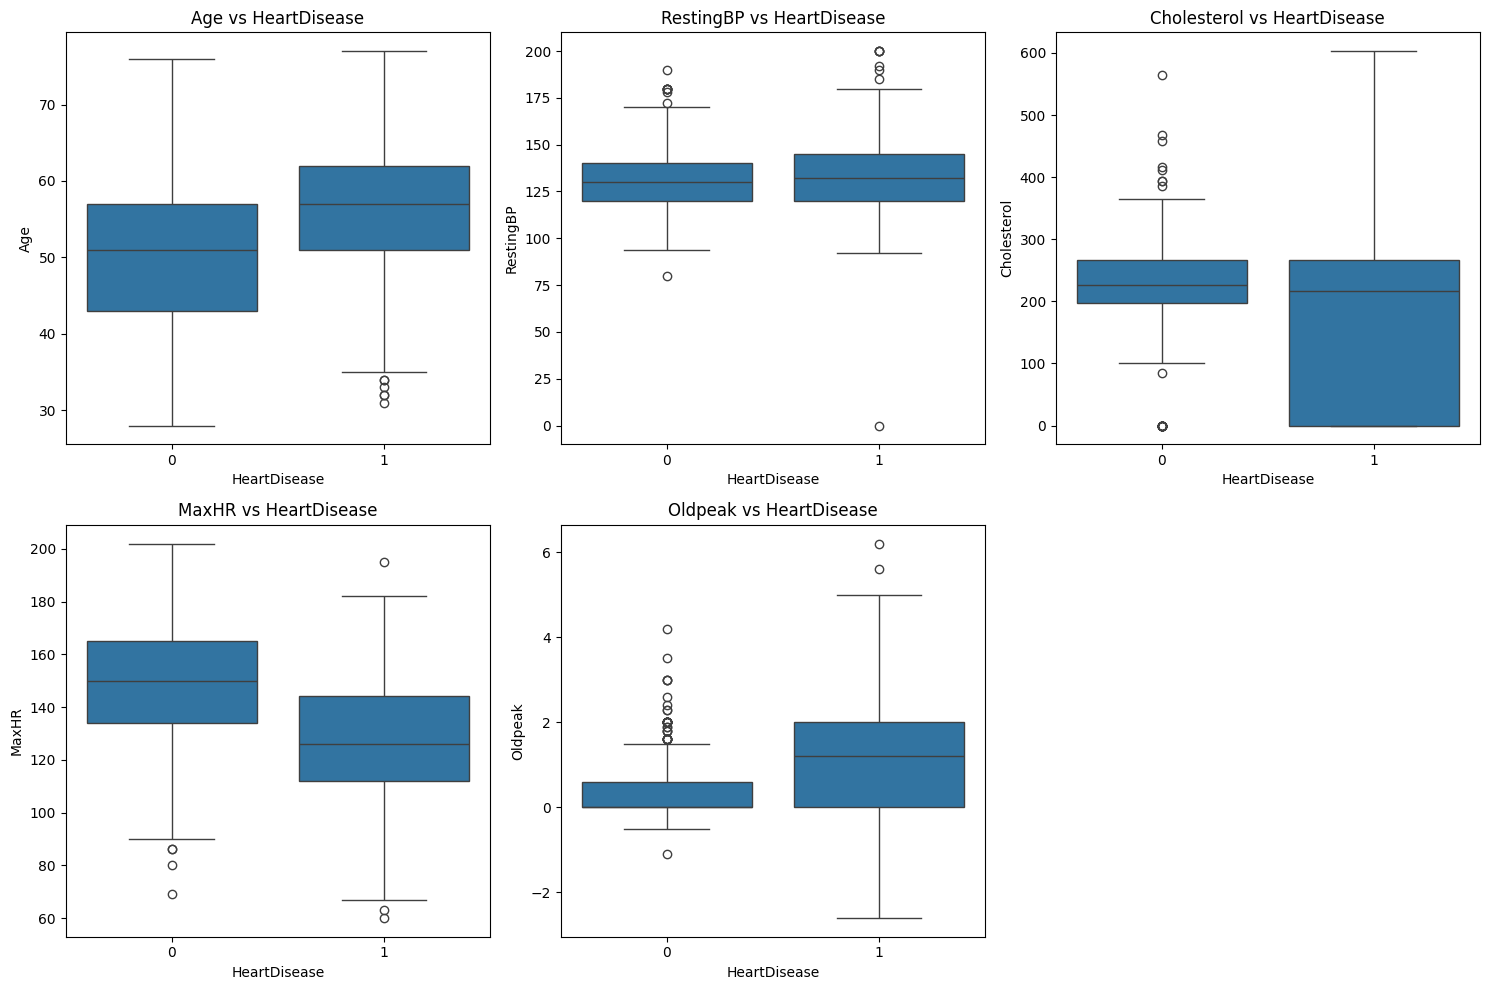

In [10]:
#Boxplot Fitur Numerik vs Target
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='HeartDisease', y=col, data=df)
    plt.title(f'{col} vs HeartDisease')

plt.tight_layout()
plt.show()


In [11]:
#Save hasil preprocessing

X_train.to_csv('X_train_processed.csv', index=False)
X_test.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Preprocessing selesai!")
print("File yang tersimpan:")
print("- X_train_processed.csv")
print("- X_test_processed.csv")
print("- y_train.csv")
print("- y_test.csv")

Preprocessing selesai!
File yang tersimpan:
- X_train_processed.csv
- X_test_processed.csv
- y_train.csv
- y_test.csv
